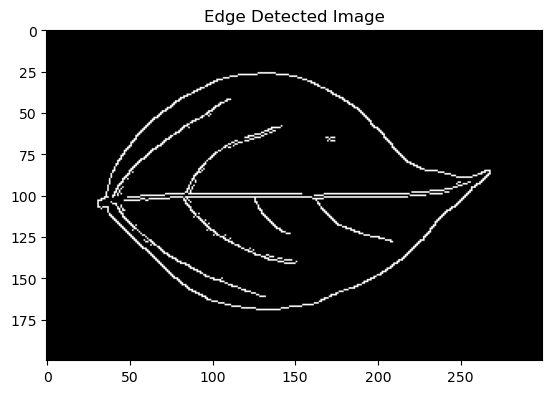

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread('imagens_teste/folha-low.jpg', cv2.IMREAD_GRAYSCALE)

# Apply Canny edge detection to find the boundary
edges = cv2.Canny(image, 100, 200)

# Display the edge-detected image
plt.imshow(edges, cmap='gray')
plt.title('Edge Detected Image')
plt.show()


In [3]:
import networkx as nx
from itertools import combinations

def create_fully_connected_boundary_graph(edges):
    # Extract boundary points from the edge-detected image
    boundary_points = np.column_stack(np.where(edges > 0))

    # Initialize the graph
    G = nx.Graph()

    # Add nodes for each boundary point
    for idx, (x, y) in enumerate(boundary_points):
        G.add_node(idx, pos=(x, y))

    # Add edges between every pair of nodes
    for (idx1, (x1, y1)), (idx2, (x2, y2)) in combinations(enumerate(boundary_points), 2):
        weight = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        G.add_edge(idx1, idx2, weight=weight)

    return G, boundary_points

# Create the graph from the boundary
graph, boundary_points = create_fully_connected_boundary_graph(edges)


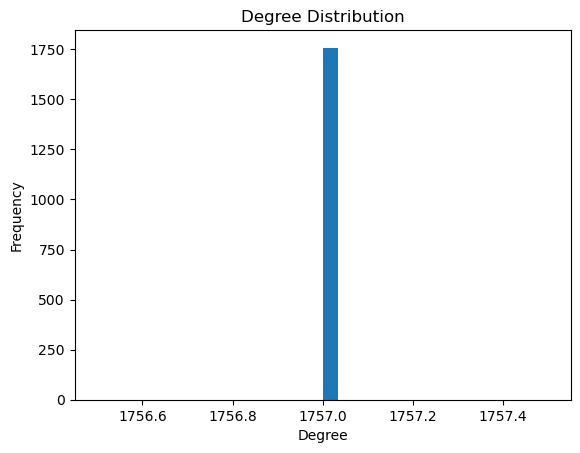

In [4]:
# Degree distribution
degree_dict = dict(graph.degree())
degrees = list(degree_dict.values())

plt.hist(degrees, bins=30)
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()


In [5]:
# Clustering coefficient
clustering_coeff = nx.clustering(graph)
avg_clustering = np.mean(list(clustering_coeff.values()))

print(f"Average Clustering Coefficient: {avg_clustering}")


Average Clustering Coefficient: 1.0


In [6]:
# Shortest path lengths
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(graph))

# Compute the average shortest path length
total_length = sum(sum(lengths.values()) for lengths in shortest_path_lengths.values())
num_paths = sum(len(lengths) for lengths in shortest_path_lengths.values())
avg_shortest_path_length = total_length / num_paths

print(f"Average Shortest Path Length: {avg_shortest_path_length}")


Average Shortest Path Length: 0.9994311717861206


In [7]:
# Random graph for comparison
random_graph = nx.erdos_renyi_graph(len(graph.nodes), 0.1)

# Compare average shortest path length
avg_shortest_path_length_random = nx.average_shortest_path_length(random_graph)
avg_clustering_random = nx.average_clustering(random_graph)

print(f"Average Shortest Path Length (Random Graph): {avg_shortest_path_length_random}")
print(f"Average Clustering Coefficient (Random Graph): {avg_clustering_random}")


Average Shortest Path Length (Random Graph): 1.899613637114147
Average Clustering Coefficient (Random Graph): 0.10035723033956001


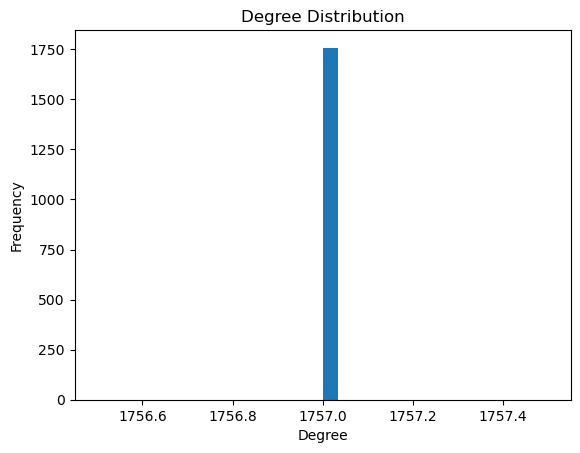

Average Clustering Coefficient: 1.0
Average Shortest Path Length: 0.9994311717861206
Average Shortest Path Length (Random Graph): 1.9003032239642115
Average Clustering Coefficient (Random Graph): 0.09960071891573925


In [9]:
import cv2
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# Load image and detect edges
image = cv2.imread('imagens_teste/folha-low.jpg', cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(image, 100, 200)

# Create fully connected graph
graph, boundary_points = create_fully_connected_boundary_graph(edges)

# Analyze degree distribution
degree_dict = dict(graph.degree())
degrees = list(degree_dict.values())
plt.hist(degrees, bins=30)
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

# Clustering coefficient
clustering_coeff = nx.clustering(graph)
avg_clustering = np.mean(list(clustering_coeff.values()))
print(f"Average Clustering Coefficient: {avg_clustering}")

# Shortest path length
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(graph))
total_length = sum(sum(lengths.values()) for lengths in shortest_path_lengths.values())
num_paths = sum(len(lengths) for lengths in shortest_path_lengths.values())
avg_shortest_path_length = total_length / num_paths
print(f"Average Shortest Path Length: {avg_shortest_path_length}")

# Comparison with random graph
random_graph = nx.erdos_renyi_graph(len(graph.nodes), 0.1)
avg_shortest_path_length_random = nx.average_shortest_path_length(random_graph)
avg_clustering_random = nx.average_clustering(random_graph)
print(f"Average Shortest Path Length (Random Graph): {avg_shortest_path_length_random}")
print(f"Average Clustering Coefficient (Random Graph): {avg_clustering_random}")


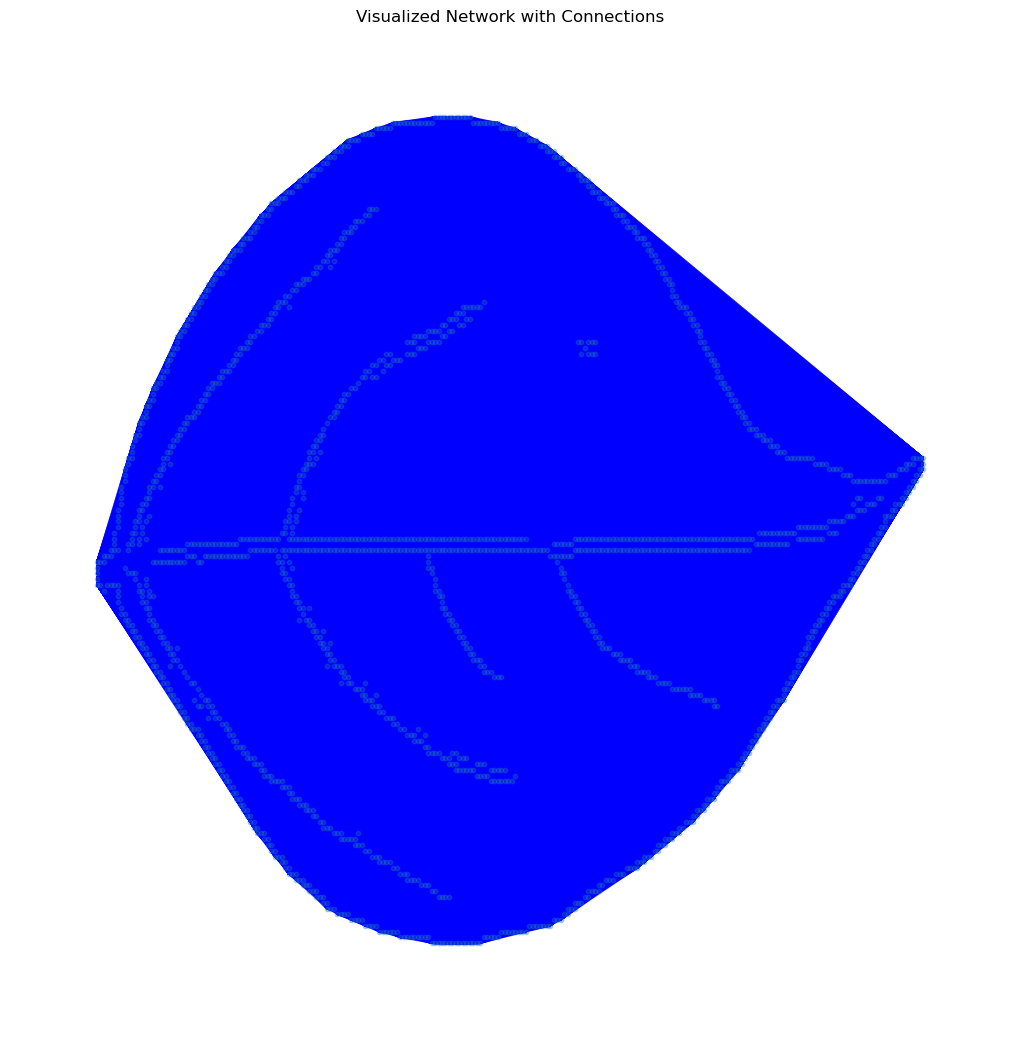

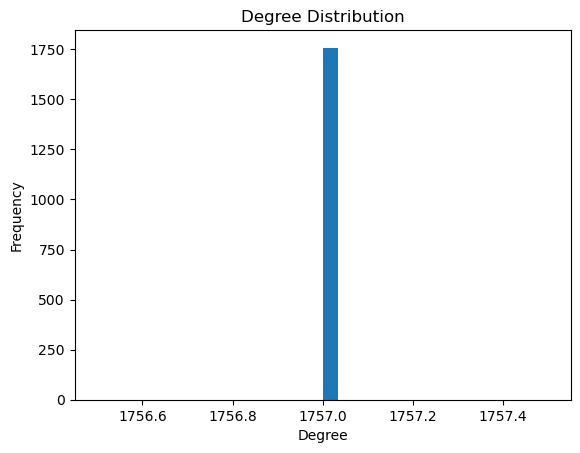

Average Clustering Coefficient: 1.0
Average Shortest Path Length: 0.9994311717861206
Average Shortest Path Length (Random Graph): 1.900272791492894
Average Clustering Coefficient (Random Graph): 0.0996258106155966


In [1]:
import cv2
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# Load image and detect edges
image = cv2.imread('imagens_teste/folha-low.jpg', cv2.IMREAD_GRAYSCALE)
edges = cv2.Canny(image, 100, 200)

# Create fully connected graph
def create_fully_connected_boundary_graph(edges):
    boundary_points = np.column_stack(np.where(edges > 0))
    G = nx.Graph()
    for (idx1, (x1, y1)), (idx2, (x2, y2)) in combinations(enumerate(boundary_points), 2):
        weight = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
        G.add_edge(idx1, idx2, weight=weight)
    return G, boundary_points

graph, boundary_points = create_fully_connected_boundary_graph(edges)

# Visualize the resulting network with connections
plt.figure(figsize=(10, 10))
pos = {i: (y, -x) for i, (x, y) in enumerate(boundary_points)}  # Adjust positions for display

# Draw the graph with node positions and edges
nx.draw(graph, pos, node_size=10, with_labels=False, edge_color='blue', alpha=0.3)
plt.title('Visualized Network with Connections')
plt.show()

# Analyze degree distribution
degree_dict = dict(graph.degree())
degrees = list(degree_dict.values())
plt.hist(degrees, bins=30)
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

# Clustering coefficient
clustering_coeff = nx.clustering(graph)
avg_clustering = np.mean(list(clustering_coeff.values()))
print(f"Average Clustering Coefficient: {avg_clustering}")

# Shortest path length
shortest_path_lengths = dict(nx.all_pairs_shortest_path_length(graph))
total_length = sum(sum(lengths.values()) for lengths in shortest_path_lengths.values())
num_paths = sum(len(lengths) for lengths in shortest_path_lengths.values())
avg_shortest_path_length = total_length / num_paths
print(f"Average Shortest Path Length: {avg_shortest_path_length}")

# Comparison with random graph
random_graph = nx.erdos_renyi_graph(len(graph.nodes), 0.1)
avg_shortest_path_length_random = nx.average_shortest_path_length(random_graph)
avg_clustering_random = nx.average_clustering(random_graph)
print(f"Average Shortest Path Length (Random Graph): {avg_shortest_path_length_random}")
print(f"Average Clustering Coefficient (Random Graph): {avg_clustering_random}")
